## 1. Data

Load the completed one-minute Binance candles collected by `crypto-candles`. This notebook no longer downloads data from Yahoo Finance.

In [8]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

# Resolve the database relative to the repository, whether the notebook
# is opened from the repository root or from the notebooks directory.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
database_path = project_root / "data" / "database" / "trading.db"
if not database_path.exists():
    raise FileNotFoundError(
        f"{database_path} was not found. Run crypto-candles or the backfill notebook first."
    )

connection = sqlite3.connect(database_path)
raw = pd.read_sql_query(
    """
    SELECT symbol, open_time_ms, open, high, low, close, volume
    FROM candles
    WHERE exchange = 'binance' AND interval_seconds = 60
    ORDER BY symbol, open_time_ms
    """,
    connection,
)
if raw.empty:
    raise ValueError("The candles table has no completed Binance one-minute rows.")

# The strategy functions use capitalized OHLCV names, so
# normalize the database columns once at the notebook boundary.
raw["time"] = pd.to_datetime(raw["open_time_ms"], unit="ms", utc=True)
frames = {}
for market_symbol, group in raw.groupby("symbol", sort=True):
    frame = group.set_index("time")[["open", "high", "low", "close", "volume"]]
    frames[market_symbol] = frame.rename(
        columns={
            "open": "Open",
            "high": "High",
            "low": "Low",
            "close": "Close",
            "volume": "Volume",
        }
    ).sort_index()

coverage = (
    raw.assign(time=pd.to_datetime(raw["open_time_ms"], unit="ms", utc=True))
    .groupby("symbol")["time"]
    .agg(first="min", last="max", rows="size")
)
coverage

,first,last,rows
symbol,,,
BTCUSDT,2026-09-08 22:32:00+00:00,2026-10-08 22:31:00+00:00,43200
DOGEUSDT,2026-09-08 22:32:00+00:00,2026-10-08 22:31:00+00:00,43200
ETHUSDT,2026-09-08 22:32:00+00:00,2026-10-08 22:31:00+00:00,43200
SOLUSDT,2026-09-08 22:32:00+00:00,2026-10-08 22:31:00+00:00,43200
XRPUSDT,2026-09-08 22:32:00+00:00,2026-10-08 22:31:00+00:00,43200


In [9]:
frames.keys()

dict_keys(['BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT'])

## 2. Settings

All strategy windows below are measured in one-minute bars. Tune on the training window and reserve the final `test_days` for testing.

In [16]:
symbol = "SOLUSDT"
sample = "train"  # "train", "test", or "all".
lookback_days = None  # None uses all stored candles; otherwise limit the window.
test_days = 7
fee = 0.000      # Assumed fee per traded dollar; slippage is not modeled.

if symbol not in frames:
    raise KeyError(f"{symbol} is not present in the candles table. Choose from {list(frames)}")
prices = frames[symbol].sort_index().copy()
if lookback_days is not None:
    cutoff = prices.index.max() - pd.Timedelta(days=lookback_days)
    prices = prices.loc[prices.index >= cutoff]
if prices.empty:
    raise ValueError("The selected symbol has no candles in the requested window.")

In [17]:
prices

,Open,High,Low,Close,Volume
time,,,,,
2026-09-08 22:32:00+00:00,103.32,103.36,103.29,103.31,231.713
2026-09-08 22:33:00+00:00,103.30,103.31,103.28,103.28,148.378
2026-09-08 22:34:00+00:00,103.29,103.29,103.21,103.25,1437.296
2026-09-08 22:35:00+00:00,103.24,103.24,103.21,103.23,277.719
2026-09-08 22:36:00+00:00,103.23,103.27,103.21,103.26,288.638
...,...,...,...,...,...
2026-10-08 22:27:00+00:00,110.34,110.35,110.29,110.29,1249.638
2026-10-08 22:28:00+00:00,110.28,110.30,110.23,110.27,2066.033
2026-10-08 22:29:00+00:00,110.26,110.26,110.22,110.24,595.463


## 3. Strategy functions

Return a Series on the price index: -1 = fully short, 0 = cash, and 1 = fully long. Return NaN during warm-up. Each rule uses only the current and earlier candles; the backtest shifts the target before earning the next candle's return.

In [18]:
from crypto_trader.strategies.sma_distance import sma_distance

def volatility_adjusted(prices, window=20, multiplier=3):
    sma = prices["Close"].rolling(window).mean()
    distance = prices["Close"] / sma - 1
    volatility = prices["Close"].pct_change().rolling(window).std()
    weight = distance / (multiplier * volatility.replace(0, float("nan")))
    # Zero volatility means cash; incomplete windows remain NaN.
    return weight.clip(-1, 1).fillna(0).where(volatility.notna() & sma.notna())

def sma_crossover(prices, short=20, long=50):
    short_sma = prices["Close"].rolling(short).mean()
    long_sma = prices["Close"].rolling(long).mean()
    return (short_sma > long_sma).astype(float).where(long_sma.notna())

def sma_threshold(prices, threshold=0.01):
    sma = prices["Close"].rolling(20).mean()
    return (((prices["Close"] - sma) / sma).abs() > threshold).astype(float).where(sma.notna())

# Copy this function and replace the rule with your own.
def my_strategy(prices):
    return pd.Series(0.0, index=prices.index)  # Placeholder: cash.

## 4. Choose strategies

Add a strategy and its parameters here. Strategies share the same evaluation dates after warm-up.

In [19]:
strategies = {
    "Original": sma_distance(prices, window=20, scale=10),
    "Volatility adjusted": volatility_adjusted(prices, window=20, multiplier=3),
    # "My strategy": my_strategy(prices),
    "Buy and hold": pd.Series(1.0, index=prices.index),
    "SMA Crossover": sma_crossover(prices),
    "SMA Threshold": sma_threshold(prices),
}
for name, weights in strategies.items():
    assert isinstance(weights, pd.Series) and weights.index.equals(prices.index), name
    assert weights.dropna().between(-1, 1).all(), f"{name}: weights must be -1 to 1"
positions = pd.DataFrame(strategies)

## 5. Shared backtest

Leave this unchanged when adding strategies. The previous target weight earns the next minute's return, so a signal cannot use a future candle. Fees approximate changes in target weights; slippage and intra-candle execution are not modeled.

In [20]:
market_returns = prices["Close"].pct_change()
held = positions.shift(1)  # Previous target earns the next minute's return.
split = prices.index.max() - pd.Timedelta(days=test_days)
periods = {"train": prices.index < split, "test": prices.index >= split,
           "all": pd.Series(True, index=prices.index)}
selected = held.notna().all(axis=1) & market_returns.notna() & periods[sample]
held = held.loc[selected]
if held.empty:
    raise ValueError("No rows to test: check the sample, test_days, and warm-up windows.")
turnover = held.diff().abs()
turnover.iloc[0] = held.iloc[0].abs()  # Initial purchase from cash.
strategy_returns = held.mul(market_returns.loc[selected], axis=0) - fee * turnover
equity = (1 + strategy_returns).cumprod()
# Include the starting $1 before the first scored return.
start_position = prices.index.get_loc(equity.index[0]) - 1
start = prices.index[start_position] if start_position >= 0 else equity.index[0]
equity = pd.concat([pd.DataFrame(1.0, index=[start], columns=equity.columns), equity])

## 6. Results

After changing a rule or parameter, rerun Settings and every cell below it.

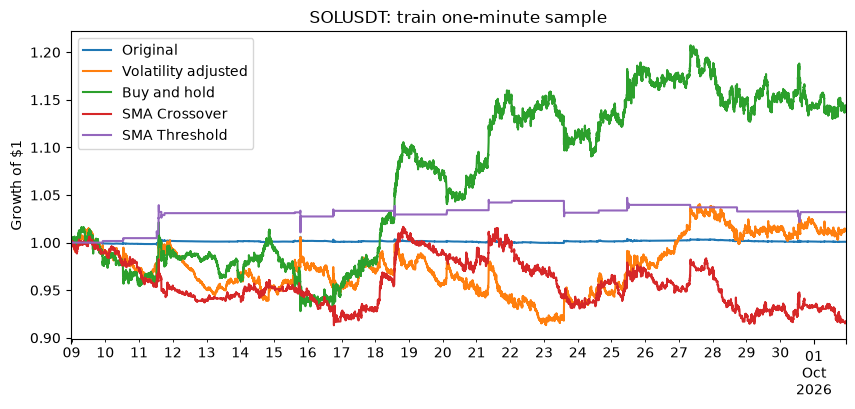

,Total return,Max drawdown,Sharpe ratio
Original,0.000845,0.006577,0.511423
Volatility adjusted,0.012070,0.100103,0.656727
Buy and hold,0.143618,0.091435,3.846030
SMA Crossover,-0.083185,0.100228,-3.070110
SMA Threshold,0.032047,0.027556,3.862974


In [21]:
equity.plot(figsize=(10, 4), title=f"{symbol}: {sample} one-minute sample", ylabel="Growth of $1")
plt.show()
summary = pd.DataFrame({
    "Total return": equity.iloc[-1] - 1,
    "Max drawdown": (1 - equity / equity.cummax()).max(),
    # There are 365*24*60 one-minute bars in a 24/7 crypto year.
    "Sharpe ratio": strategy_returns.mean() / strategy_returns.std() * (365 * 24 * 60) ** 0.5,
})
summary